# Negative-bucket threshold for the sentiment-bucket scoring runs (RavenBERT)

The sentiment-bucket runs of `narrative_daily` will split the headlines into **negative**
(SENT ≤ NEG_MAX), **positive + neutral** (SENT > NEG_MAX) and **unscored**. Only NEG_MAX is
chosen here. This notebook describes five candidate cuts, NEG_MAX ∈ {−0.10, −0.20, −0.25, −1/3,
−0.50}; it does not pick one.

**In-sample only.** Everything read ends on 2019-12-31; 2020 onward is out-of-sample and never
enters a figure or a table (asserted after every load). The datalake is only read; monthly
aggregates are cached in `.cache/` next to the notebook (git-ignored), built by
`daily_sentiment.py` (`load_cut_counts`: one DuckDB pass per month for all cuts,
~1–2 s a month; `load_sample`: the headline sample, <1 s a month). First run ≈ 7–8 min.

| quantity | definition |
|---|---|
| source | latest complete `headline_sentiment` artifact of `ravenbert` |
| SENT | ordinal **mean** of the headline's predicted distribution on the 41-point grid (rule `mean`, as the bucket runs) |
| CONF | 1 − standard deviation of that distribution; `min_conf = 0`, so unscored = no model output |
| share negative | headlines with SENT ≤ NEG_MAX / headlines with a model output (the scoring's `<=` predicate) |
| SENT_ARGMAX | the `argmax` rule (a grid point), shown only to explain where the "neutral majority" comes from |
| P_ZERO | the predicted mass on the grid point s = 0 |

**Why "exact zero" is split by rule.** Under the `mean` rule SENT is a probability-weighted
average of the grid, so SENT == 0 exactly essentially never happens; the neutral spike lives in
the model's mass at s = 0 (P_ZERO) and in the `argmax` rule, which lands on s = 0 for most
headlines. Section 1 therefore shows the `mean`-rule SENT on the 41 grid bins (central bin
|SENT| < 0.025 highlighted), the `argmax` SENT split into exact zero and the rest, and P_ZERO.

Days are UTC calendar days (weekends included); weeks run Monday–Sunday, are labelled by their
Monday and are kept only when complete (7 days).

In [1]:
import os
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex
from nlp.sentiment.base import GRID, GRID_EDGES
from daily_sentiment import load_cut_counts, load_sample, locate, neg_col

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(60); pl.Config.set_tbl_width_chars(250); pl.Config.set_tbl_cols(30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- source ---------------------------------------------------------------------------
SOURCE = "ravenbert"            # headline_sentiment producer
SENTIMENT_ID = None             # None = the latest complete artifact of SOURCE
RULE = "mean"                   # the bucket runs' sentiment_rule; min_conf = 0
CACHE_DIR = Path(".cache")

# ---- candidate cuts: negative bucket = SENT <= NEG_MAX --------------------------------
CUTS = (-0.10, -0.20, -0.25, -1.0 / 3.0, -0.50)
LABEL = {c: ("-1/3" if c == -1.0 / 3.0 else f"{c:+.2f}") for c in CUTS}
COLOR = dict(zip(CUTS, plt.cm.plasma(np.linspace(0.05, 0.85, len(CUTS)))))

# ---- windows (in-sample only) ---------------------------------------------------------
IS_END = date(2019, 12, 31)                          # 2020+ is out-of-sample: never read
SERIES = (date(2000, 1, 1), IS_END)                  # section 2 daily series
SAMPLE = (date(2007, 1, 1), IS_END)                  # section 1 headline sample
SAMPLE_RATE, SEED = 0.01, 20070101
STABILITY = (date(2007, 1, 1), IS_END)               # section 4
FEED_BREAK = date(2006, 10, 1)                       # flow ~x3 from 2006-10 (feed change)
BASELINE = (date(2006, 11, 1), date(2007, 6, 30))    # GFC reference, after the feed break
ROLL = 20                                            # days

# event dates; the event week is the Monday-labelled week containing the date
GFC_EVENTS = {
    "BNP funds frozen": date(2007, 8, 9),
    "Bear Stearns": date(2008, 3, 14),
    "Lehman": date(2008, 9, 15),
    "Coordinated cut": date(2008, 10, 8),
    "NBER call": date(2008, 12, 1),
    "Equity trough": date(2009, 3, 9),
}
LATER_EVENTS = {                                     # each vs the 52 preceding complete weeks
    "US downgrade": date(2011, 8, 8),       # S&P cut Fri 2011-08-05 after the close: reaction week
    "China devaluation": date(2015, 8, 11),
    "Dec-2018 selloff": date(2018, 12, 17), # FOMC hike 12-19, worst week of the selloff
}
LATER_BASE_WEEKS = 52

assert max([*GFC_EVENTS.values(), *LATER_EVENTS.values(), SERIES[1], SAMPLE[1]]) <= IS_END


def week_of(d: date) -> date:
    return d - timedelta(days=d.weekday())


def share_col(c: float) -> str:
    return f"SHARE{c:+.4f}"


def date_axis(ax, lo, hi):
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_locator(mdates.YearLocator(2 if (hi - lo).days > 3000 else 1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

## 1. Distribution shape

A 1% uniform headline sample, 2007-01..2019-12: a headline is kept iff
hash(RP_STORY_ID, SEED) mod 10⁶ < 10⁴ (deterministic, independent of file order and threads).

In [2]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
SRC = locate(dl, SOURCE, SENTIMENT_ID)
print("sentiment:", SRC.sentiment_id)
print("headlines:", SRC.headlines_id)

sample = load_sample(SRC, *SAMPLE, CACHE_DIR, rate=SAMPLE_RATE, seed=SEED)
assert sample["DATE"].max() <= IS_END and sample["DATE"].min() >= SAMPLE[0]
sample = sample.with_columns(pl.col("DATE").dt.year().alias("YEAR"))
sc = sample.drop_nulls("SENT")
print(f"{sample.height:,} sampled headlines, {sc.height:,} with a model output "
      f"({sc.height / sample.height:.4%}); {sample['DATE'].min()} .. {sample['DATE'].max()}")

sentiment: headline_sentiment__ravenbert-sentiment-2.1__v0.2.0__params0f2600a3__20260928
headlines: ravenpack_headlines__v0.1.0__end_year2025_start_year2000__20260911
aggregating sample_r0.0100_s20070101 2007-01 ...
aggregating sample_r0.0100_s20070101 2007-02 ...
aggregating sample_r0.0100_s20070101 2007-03 ...
aggregating sample_r0.0100_s20070101 2007-04 ...
aggregating sample_r0.0100_s20070101 2007-05 ...
aggregating sample_r0.0100_s20070101 2007-06 ...
aggregating sample_r0.0100_s20070101 2007-07 ...
aggregating sample_r0.0100_s20070101 2007-08 ...
aggregating sample_r0.0100_s20070101 2007-09 ...
aggregating sample_r0.0100_s20070101 2007-10 ...
aggregating sample_r0.0100_s20070101 2007-11 ...
aggregating sample_r0.0100_s20070101 2007-12 ...
aggregating sample_r0.0100_s20070101 2008-01 ...
aggregating sample_r0.0100_s20070101 2008-02 ...
aggregating sample_r0.0100_s20070101 2008-03 ...
aggregating sample_r0.0100_s20070101 2008-04 ...
aggregating sample_r0.0100_s20070101 2008-05 ...


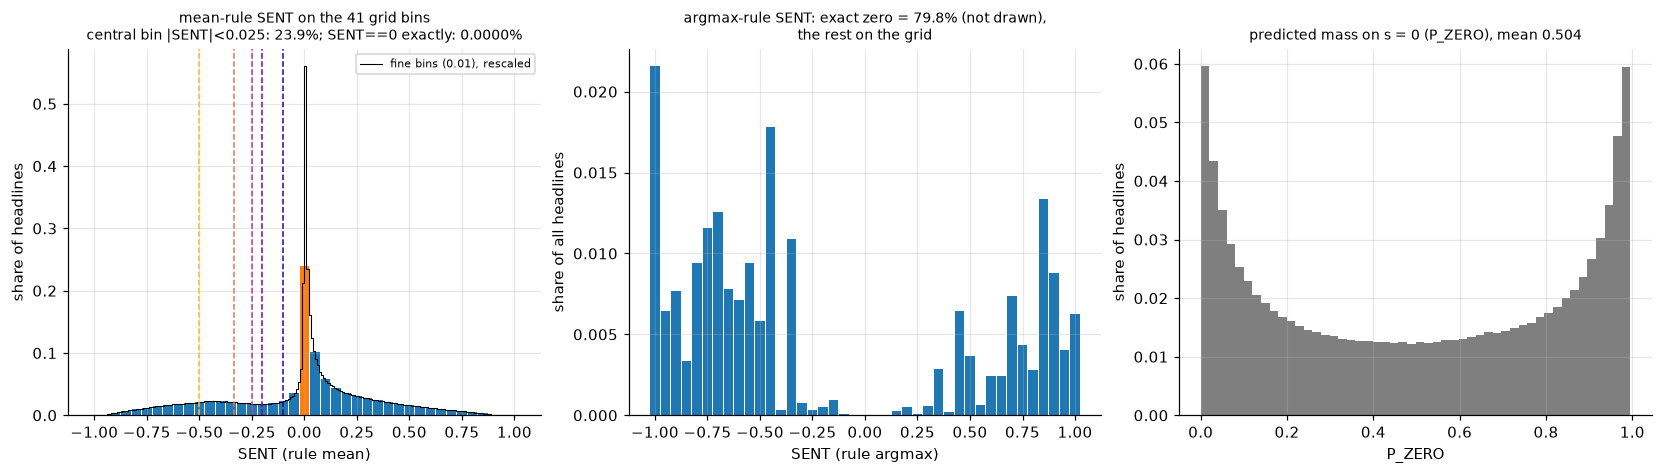

In [3]:
NB = len(GRID)
MID = NB // 2                                            # grid index of s = 0
sent = sc["SENT"].to_numpy()
arg = sc["SENT_ARGMAX"].to_numpy()
h_mean = np.histogram(sent, bins=GRID_EDGES)[0] / len(sent)
arg_idx = np.clip(np.rint((arg + 1) / 0.05).astype(int), 0, NB - 1)   # argmax ties can fall between points
h_arg = np.bincount(arg_idx, minlength=NB) / len(arg)
zero_arg = float(np.mean(arg == 0.0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
ax.bar(GRID, h_mean, width=0.045, color=["tab:orange" if j == MID else "tab:blue" for j in range(NB)])
fine = np.linspace(-1, 1, 201)
ax.step(fine[:-1], np.histogram(sent, bins=fine)[0] / len(sent) * (0.05 / 0.01), where="post",
        color="k", lw=0.7, label="fine bins (0.01), rescaled")
for c in CUTS:
    ax.axvline(c, color=COLOR[c], lw=1, ls="--")
ax.set_title(f"mean-rule SENT on the 41 grid bins\ncentral bin |SENT|<0.025: {h_mean[MID]:.1%}; "
             f"SENT==0 exactly: {np.mean(sent == 0.0):.4%}", fontsize=9)
ax.set_xlabel("SENT (rule mean)"); ax.set_ylabel("share of headlines"); ax.legend(fontsize=7)

ax = axes[1]
rest = h_arg.copy(); rest[MID] = 0.0
ax.bar(GRID, rest, width=0.045, color="tab:blue")
ax.set_title(f"argmax-rule SENT: exact zero = {zero_arg:.1%} (not drawn),\nthe rest on the grid", fontsize=9)
ax.set_xlabel("SENT (rule argmax)"); ax.set_ylabel("share of all headlines")

ax = axes[2]
ax.hist(sc["P_ZERO"].to_numpy(), bins=50, color="tab:gray", weights=np.full(sc.height, 1 / sc.height))
ax.set_title(f"predicted mass on s = 0 (P_ZERO), mean {sc['P_ZERO'].mean():.3f}", fontsize=9)
ax.set_xlabel("P_ZERO"); ax.set_ylabel("share of headlines")
plt.show()

**Per year (drift).** Left: the `mean`-rule histogram on the grid bins, one line per year.
Right: the `argmax` rest (exact zero excluded). The table gives the zero-mass measures and the
sample's share below each cut per year.

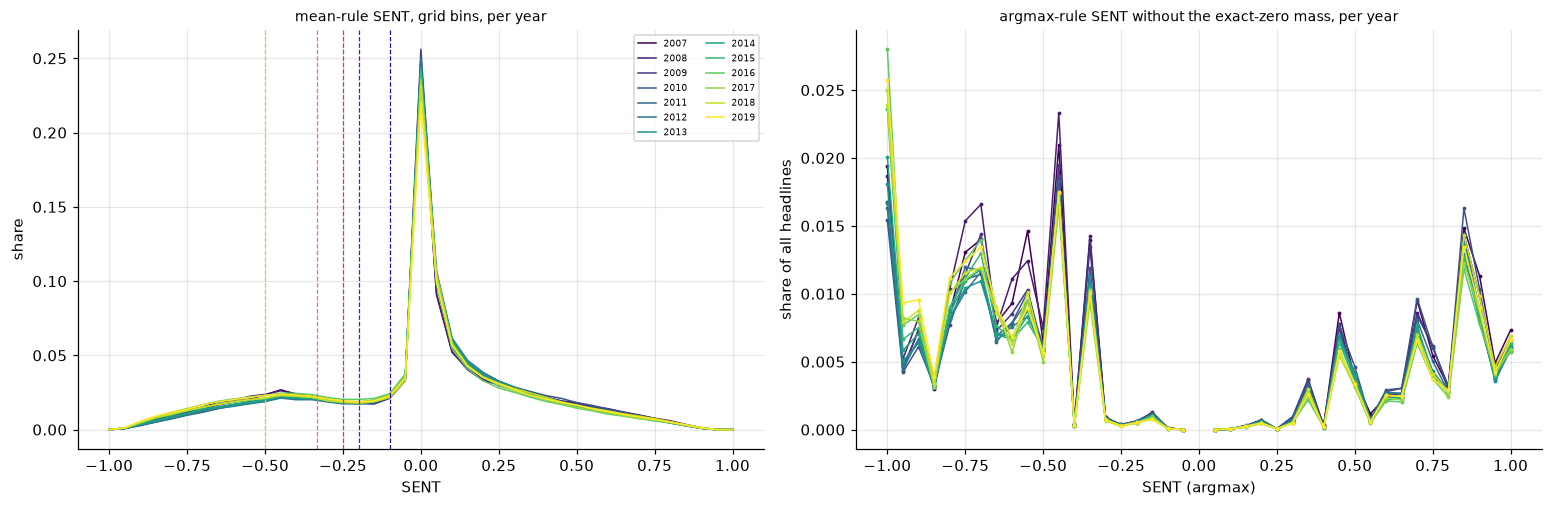

YEAR,N,argmax_exact_zero,mean_exact_zero,mean_central_bin,mean_P_ZERO,median_CONF,share<=-0.10,share<=-0.20,share<=-0.25,share<=-1/3,share<=-0.50
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2007,124007,0.7729,0.0,0.243,0.4848,0.7855,0.2818,0.2441,0.2262,0.1925,0.1107
2008,141079,0.7665,0.0,0.2454,0.4835,0.7876,0.2904,0.2536,0.2361,0.2019,0.121
2009,169478,0.7923,0.0,0.256,0.5053,0.79,0.2644,0.2268,0.2087,0.1764,0.1024
2010,188101,0.7958,0.0,0.2444,0.5012,0.7874,0.2505,0.214,0.1965,0.1653,0.0951
2011,269614,0.8035,0.0,0.2477,0.5112,0.7898,0.2577,0.2194,0.2018,0.17,0.0993
2012,345448,0.8122,0.0,0.2503,0.5192,0.7912,0.2488,0.2117,0.1943,0.1637,0.0958
2013,351143,0.81,0.0,0.2429,0.514,0.7892,0.2581,0.2194,0.2014,0.1691,0.0986
2014,374693,0.8087,0.0,0.2438,0.5142,0.7878,0.2659,0.2271,0.2086,0.1763,0.1051
2015,411566,0.8028,0.0,0.2421,0.5093,0.7862,0.2802,0.2403,0.2217,0.1886,0.1149


In [4]:
years = sorted(sc["YEAR"].unique().to_list())
cmap = plt.cm.viridis(np.linspace(0, 1, len(years)))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for y, col in zip(years, cmap):
    g = sc.filter(pl.col("YEAR") == y)
    s_ = g["SENT"].to_numpy(); a_ = g["SENT_ARGMAX"].to_numpy()
    axes[0].plot(GRID, np.histogram(s_, bins=GRID_EDGES)[0] / len(s_), color=col, lw=1, label=str(y))
    ai = np.clip(np.rint((a_ + 1) / 0.05).astype(int), 0, NB - 1)
    ha = np.bincount(ai, minlength=NB) / len(a_); ha[MID] = np.nan
    axes[1].plot(GRID, ha, color=col, lw=1, marker=".", ms=3)
for c in CUTS:
    axes[0].axvline(c, color=COLOR[c], lw=0.8, ls="--")
axes[0].set_title("mean-rule SENT, grid bins, per year", fontsize=9); axes[0].set_xlabel("SENT")
axes[0].set_ylabel("share"); axes[0].legend(fontsize=6, ncol=2)
axes[1].set_title("argmax-rule SENT without the exact-zero mass, per year", fontsize=9)
axes[1].set_xlabel("SENT (argmax)"); axes[1].set_ylabel("share of all headlines")
plt.show()

by_year = (sc.group_by("YEAR").agg(
    pl.len().alias("N"),
    (pl.col("SENT_ARGMAX") == 0.0).mean().alias("argmax_exact_zero"),
    (pl.col("SENT") == 0.0).mean().alias("mean_exact_zero"),
    (pl.col("SENT").abs() < 0.025).mean().alias("mean_central_bin"),
    pl.col("P_ZERO").mean().alias("mean_P_ZERO"),
    pl.col("CONF").median().alias("median_CONF"),
    *[(pl.col("SENT") <= c).mean().alias(f"share<={LABEL[c]}") for c in CUTS],
).sort("YEAR"))
by_year.with_columns(pl.selectors.float().round(4))

**CONF.** With `min_conf = 0` CONF filters nothing; its shape says how much a CONF floor would
move headlines to *unscored* if one were used later. Split by bucket side at the default cut.

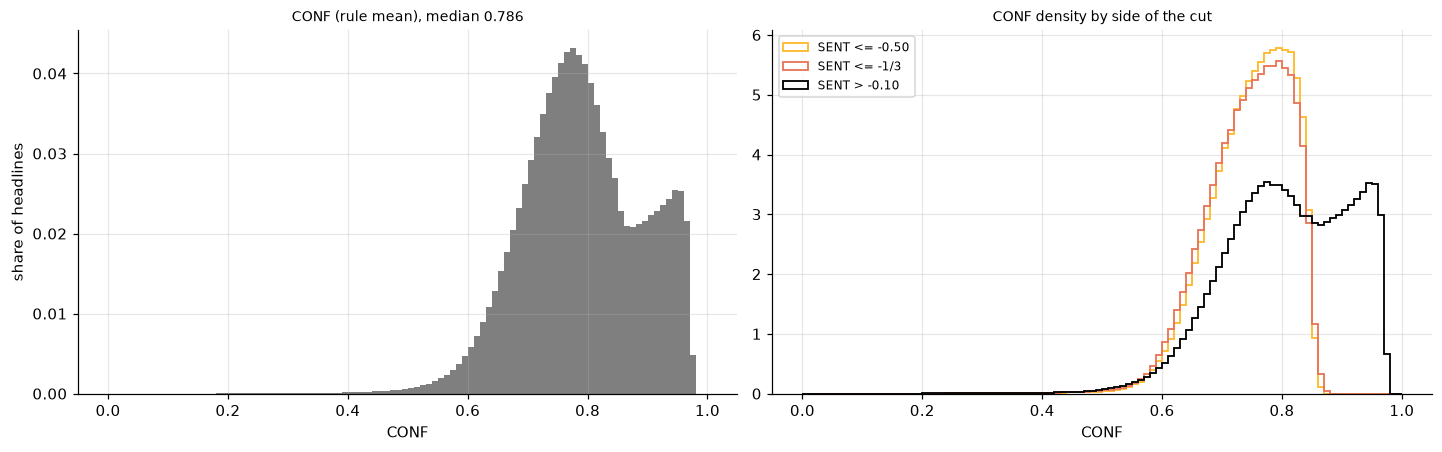

In [5]:
conf = sc["CONF"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, 1, 101)
axes[0].hist(conf, bins=bins, weights=np.full(len(conf), 1 / len(conf)), color="tab:gray")
axes[0].set_title(f"CONF (rule mean), median {np.median(conf):.3f}", fontsize=9)
axes[0].set_xlabel("CONF"); axes[0].set_ylabel("share of headlines")
for c, lab in ((-0.50, "SENT <= -0.50"), (-1 / 3, "SENT <= -1/3")):
    x = conf[sent <= c]
    axes[1].hist(x, bins=bins, density=True, histtype="step", lw=1.2, color=COLOR[c], label=lab)
x = conf[sent > -0.10]
axes[1].hist(x, bins=bins, density=True, histtype="step", lw=1.2, color="k", label="SENT > -0.10")
axes[1].set_title("CONF density by side of the cut", fontsize=9); axes[1].set_xlabel("CONF")
axes[1].legend(fontsize=8)
plt.show()

## 2. Bucket share over time

Daily counts of SENT ≤ NEG_MAX per (day, news type) for all five cuts in one pass, 2000–2019.
The 20-day share is the ratio of 20-day rolling sums (days weighted by their flow). Solid: all
news types; dashed: FULL-ARTICLE only. Dotted vertical line: the 2006-10 feed break.

aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-01 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-02 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-03 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-04 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-05 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-06 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-07 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-08 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-09 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-10 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-11 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2000-12 ...
aggregating cuts_mean_-0.5000_-0.3333_-0.2500_-0.2000_-0.1000 2001-01 ...
aggregating cuts_mean_-0.5000_-0.3333_

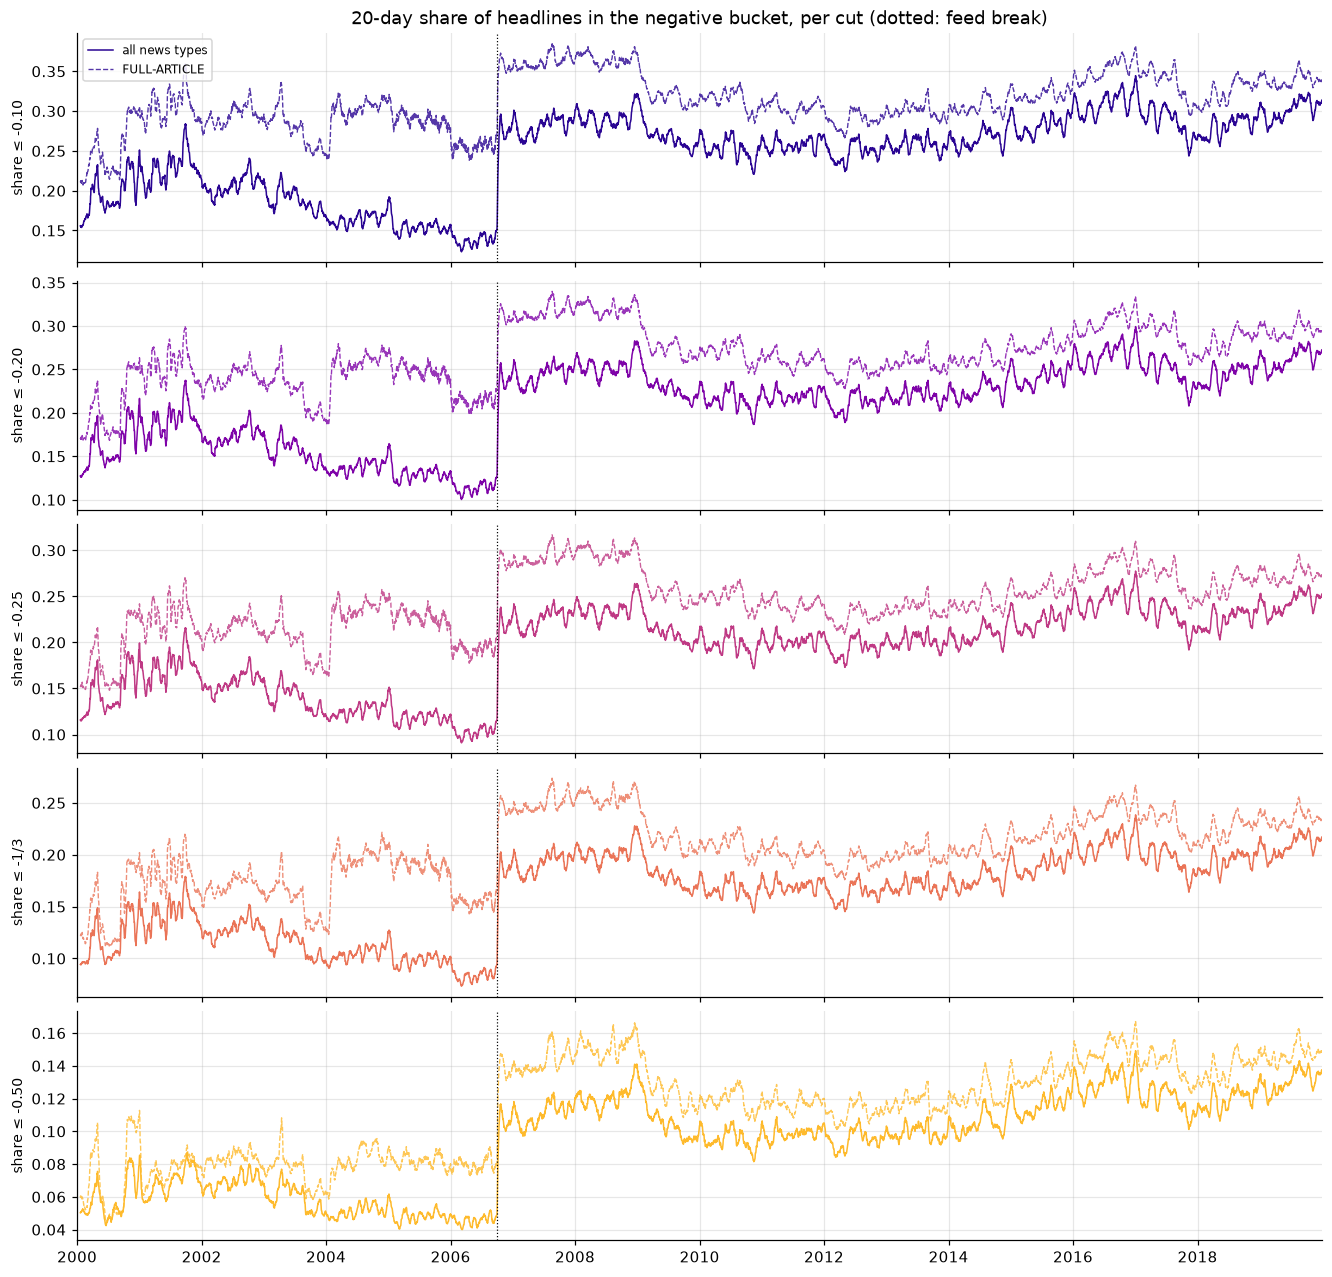

In [6]:
counts = load_cut_counts(SRC, *SERIES, CACHE_DIR, CUTS, rule=RULE)
assert counts["DATE"].max() <= IS_END
NEG = [neg_col(c) for c in CUTS]


def agg(df: pl.DataFrame, by: list[str]) -> pl.DataFrame:
    return df.group_by(by).agg(pl.col("N", "N_SCORED", *NEG).sum()).sort(by)


def with_shares(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([(pl.col(neg_col(c)) / pl.col("N_SCORED")).alias(share_col(c)) for c in CUTS])


day_all = agg(counts, ["DATE"])
day_fa = agg(counts.filter(pl.col("NEWS_TYPE") == "FULL-ARTICLE"), ["DATE"])
print(f"{day_all.height:,} days, {int(day_all['N'].sum()):,} headlines; "
      f"unscored (no model output) {1 - day_all['N_SCORED'].sum() / day_all['N'].sum():.5%}; "
      f"FULL-ARTICLE {day_fa['N'].sum() / day_all['N'].sum():.1%} of the flow")


def rolling_shares(day: pl.DataFrame) -> pl.DataFrame:
    return day.with_columns(
        [(pl.col(neg_col(c)).rolling_sum(ROLL) / pl.col("N_SCORED").rolling_sum(ROLL)).alias(share_col(c))
         for c in CUTS])


r_all, r_fa = rolling_shares(day_all), rolling_shares(day_fa)
fig, axes = plt.subplots(len(CUTS), 1, figsize=(12, 2.3 * len(CUTS)), sharex=True)
for ax, c in zip(axes, CUTS):
    ax.plot(r_all["DATE"], r_all[share_col(c)], color=COLOR[c], lw=1, label="all news types")
    ax.plot(r_fa["DATE"], r_fa[share_col(c)], color=COLOR[c], lw=0.9, ls="--", alpha=0.8, label="FULL-ARTICLE")
    ax.axvline(FEED_BREAK, color="k", lw=0.8, ls=":")
    ax.set_ylabel(f"share ≤ {LABEL[c]}", fontsize=9)
    date_axis(ax, *SERIES)
axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_title(f"{ROLL}-day share of headlines in the negative bucket, per cut (dotted: feed break)")
plt.show()

## 3. Event contrast

Weekly share negative (complete weeks). GFC events: z against the baseline
2006-11-01..2007-06-30 (complete weeks inside it), ratio = event-week share / baseline mean
share. Later events: the same against the 52 complete weeks before the event week. A cut that
separates crisis weeks well has a high z (signal over week-to-week noise) and a high ratio
(the bucket's size moves in relative terms, which is what the bucket-run attention measures see).

In [7]:
def weekly(day: pl.DataFrame) -> pl.DataFrame:
    return with_shares(day.with_columns(pl.col("DATE").dt.truncate("1w").alias("WEEK"))
                       .group_by("WEEK").agg(pl.col("N", "N_SCORED", *NEG).sum(), pl.len().alias("DAYS"))
                       .filter(pl.col("DAYS") == 7).sort("WEEK"))


wk_all, wk_fa = weekly(day_all), weekly(day_fa)
base = wk_all.filter((pl.col("WEEK") >= BASELINE[0]) & (pl.col("WEEK") + timedelta(days=6) <= BASELINE[1]))
print(f"baseline: {base.height} complete weeks, {base['WEEK'].min()} .. {base['WEEK'].max()}")

rows = []
for c in CUTS:
    s = share_col(c)
    m, sd = base[s].mean(), base[s].std()
    for ev, d in GFC_EVENTS.items():
        v = wk_all.filter(pl.col("WEEK") == week_of(d))[s].item()
        rows.append({"cut": LABEL[c], "group": "GFC", "event": ev, "week": week_of(d), "share": v,
                     "ref_share": m, "z": (v - m) / sd, "ratio": v / m})
    for ev, d in LATER_EVENTS.items():
        w = week_of(d)
        prev = wk_all.filter(pl.col("WEEK") < w).tail(LATER_BASE_WEEKS)
        assert prev.height == LATER_BASE_WEEKS and prev["WEEK"].min() == w - timedelta(weeks=LATER_BASE_WEEKS), ev
        v = wk_all.filter(pl.col("WEEK") == w)[s].item()
        pm, ps = prev[s].mean(), prev[s].std()
        rows.append({"cut": LABEL[c], "group": "later", "event": ev, "week": w, "share": v,
                     "ref_share": pm, "z": (v - pm) / ps, "ratio": v / pm})
events = pl.DataFrame(rows)

ORDER = [*GFC_EVENTS, *LATER_EVENTS]
z_tab = events.pivot(on="event", index="cut", values="z").select("cut", *ORDER)
r_tab = events.pivot(on="event", index="cut", values="ratio").select("cut", *ORDER)
size = pl.DataFrame({"cut": [LABEL[c] for c in CUTS],
                     "baseline_share": [base[share_col(c)].mean() for c in CUTS],
                     "baseline_weekly_sd": [base[share_col(c)].std() for c in CUTS]}) \
    .with_columns((pl.col("baseline_weekly_sd") / pl.col("baseline_share")).alias("baseline_cv"))

print("z of the event-week share negative (rows: cut)")
display(z_tab.with_columns(pl.selectors.float().round(2)))
print("ratio event-week share / reference share")
display(r_tab.with_columns(pl.selectors.float().round(3)))
print("baseline bucket size (2006-11..2007-06, complete weeks, all news types)")
display(size.with_columns(pl.selectors.float().round(4)))

baseline: 33 complete weeks, 2006-11-06 .. 2007-06-18
z of the event-week share negative (rows: cut)


cut,BNP funds frozen,Bear Stearns,Lehman,Coordinated cut,NBER call,Equity trough,US downgrade,China devaluation,Dec-2018 selloff
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""-0.10""",0.87,1.78,1.73,2.52,3.23,-0.38,0.59,1.11,1.45
"""-0.20""",0.99,1.84,1.87,2.65,3.57,-0.46,0.56,1.23,1.63
"""-0.25""",1.08,1.86,1.94,2.83,3.73,-0.51,0.53,1.29,1.73
"""-1/3""",1.32,2.03,2.06,2.94,4.14,-0.55,0.48,1.41,1.83
"""-0.50""",1.85,2.58,3.45,3.97,5.33,0.25,0.53,1.76,2.05


ratio event-week share / reference share


cut,BNP funds frozen,Bear Stearns,Lehman,Coordinated cut,NBER call,Equity trough,US downgrade,China devaluation,Dec-2018 selloff
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""-0.10""",1.043,1.089,1.086,1.125,1.16,0.981,1.031,1.059,1.076
"""-0.20""",1.052,1.097,1.099,1.14,1.188,0.976,1.032,1.07,1.089
"""-0.25""",1.058,1.1,1.104,1.151,1.2,0.973,1.031,1.075,1.096
"""-1/3""",1.072,1.111,1.113,1.161,1.227,0.97,1.029,1.088,1.104
"""-0.50""",1.115,1.16,1.213,1.245,1.33,1.015,1.038,1.128,1.127


baseline bucket size (2006-11..2007-06, complete weeks, all news types)


cut,baseline_share,baseline_weekly_sd,baseline_cv
str,f64,f64,f64
"""-0.10""",0.2748,0.0137,0.0497
"""-0.20""",0.2373,0.0125,0.0528
"""-0.25""",0.2195,0.0118,0.0536
"""-1/3""",0.186,0.0102,0.0547
"""-0.50""",0.1058,0.0065,0.0619


The same z over the whole GFC stretch, per cut (baseline mean and σ of each cut), to see
whether the event weeks are peaks or samples of a broad shift.

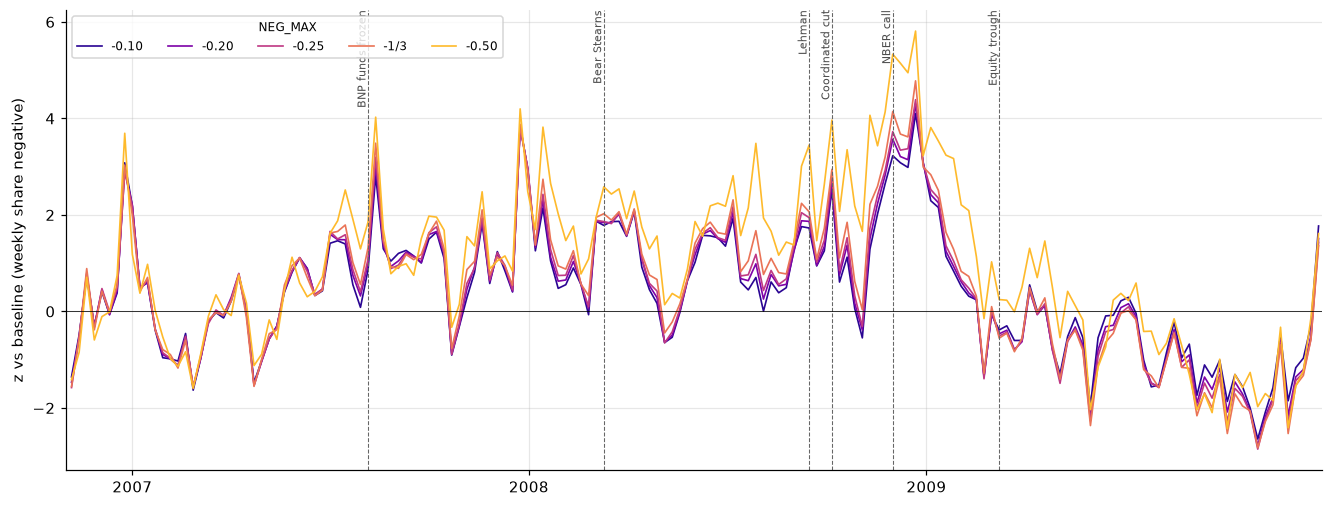

In [8]:
view = (date(2006, 11, 1), date(2009, 12, 31))
wv = wk_all.filter(pl.col("WEEK").is_between(*view))
fig, ax = plt.subplots(figsize=(12, 4.5))
for c in CUTS:
    s = share_col(c)
    ax.plot(wv["WEEK"], (wv[s] - base[s].mean()) / base[s].std(), color=COLOR[c], lw=1.1, label=LABEL[c])
for ev, d in GFC_EVENTS.items():
    ax.axvline(week_of(d), color="0.4", lw=0.7, ls="--")
    ax.text(week_of(d), ax.get_ylim()[1], f" {ev}", rotation=90, va="top", ha="right", fontsize=7, color="0.3")
ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("z vs baseline (weekly share negative)")
ax.legend(fontsize=8, ncol=5, loc="upper left", title="NEG_MAX", title_fontsize=8)
date_axis(ax, *view)
plt.show()

## 4. Stability

Weekly share negative over the complete weeks of 2007–2019. AC1 on levels mixes the slow
drift of the flow with persistence, so AC1 of the deviation from the trailing 52-week mean is
shown next to it. Weekend / weekday: pooled share on Saturdays and Sundays over pooled share on
Monday–Friday; a cut whose bucket is mostly the thin, flat part of the distribution near the
neutral mass moves with the weekend mix (fewer, more negative headlines) more than with news.

In [9]:
def ac1(x: np.ndarray) -> float:
    x = x[~np.isnan(x)]
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])


def weekend_ratio(day: pl.DataFrame, c: float) -> float:
    d = day.filter(pl.col("DATE").is_between(*STABILITY)).with_columns(
        (pl.col("DATE").dt.weekday() >= 6).alias("WE"))
    g = d.group_by("WE").agg(pl.col(neg_col(c), "N_SCORED").sum())
    sh = {r["WE"]: r[neg_col(c)] / r["N_SCORED"] for r in g.iter_rows(named=True)}
    return sh[True] / sh[False]


ws = wk_all.filter(pl.col("WEEK").is_between(*STABILITY))
stab_rows = []
for c in CUTS:
    s = share_col(c)
    dev = ws.select(pl.col(s) - pl.col(s).shift(1).rolling_mean(LATER_BASE_WEEKS))[s].to_numpy()
    stab_rows.append({"cut": LABEL[c], "weeks": ws.height, "mean_share": ws[s].mean(),
                      "ac1_level": ac1(ws[s].to_numpy()), "ac1_dev_52w": ac1(dev),
                      "weekend/weekday": weekend_ratio(day_all, c),
                      "weekend/weekday FULL-ARTICLE": weekend_ratio(day_fa, c)})
stability = pl.DataFrame(stab_rows)
we_flow = day_all.filter(pl.col("DATE").is_between(*STABILITY)).select(
    (pl.col("N").filter(pl.col("DATE").dt.weekday() >= 6).sum() / pl.col("N").sum())).item()
print(f"weekend share of the flow 2007-2019: {we_flow:.2%}")
stability.with_columns(pl.selectors.float().round(4))

weekend share of the flow 2007-2019: 12.31%


cut,weeks,mean_share,ac1_level,ac1_dev_52w,weekend/weekday,weekend/weekday FULL-ARTICLE
str,i64,f64,f64,f64,f64,f64
"""-0.10""",678,0.2762,0.8652,0.7336,1.2314,1.0981
"""-0.20""",678,0.2373,0.8704,0.7335,1.2282,1.0908
"""-0.25""",678,0.2191,0.8736,0.7338,1.2263,1.0875
"""-1/3""",678,0.1862,0.8805,0.7346,1.2234,1.083
"""-0.50""",678,0.1114,0.8983,0.7421,1.2253,1.0863


## Verdict table

Per cut: baseline bucket size, mean z and mean ratio over the six GFC event weeks, the same over
the three later events (each vs its preceding 12 months), weekly AC1, and the weekend/weekday
share ratio. No decision here.

In [10]:
ev_mean = events.group_by("cut", "group").agg(pl.col("z").mean(), pl.col("ratio").mean())
verdict = (size.select("cut", "baseline_share", "baseline_cv")
           .join(ev_mean.filter(pl.col("group") == "GFC").select("cut", pl.col("z").alias("GFC_mean_z"),
                                                                  pl.col("ratio").alias("GFC_mean_ratio")), on="cut")
           .join(ev_mean.filter(pl.col("group") == "later").select("cut", pl.col("z").alias("later_mean_z"),
                                                                    pl.col("ratio").alias("later_mean_ratio")), on="cut")
           .join(stability.select("cut", "ac1_level", "ac1_dev_52w", "weekend/weekday"), on="cut"))
verdict = verdict.sort(pl.col("cut").replace_strict({LABEL[c]: i for i, c in enumerate(CUTS)}))
verdict.with_columns(pl.selectors.float().round(3))

cut,baseline_share,baseline_cv,GFC_mean_z,GFC_mean_ratio,later_mean_z,later_mean_ratio,ac1_level,ac1_dev_52w,weekend/weekday
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""-0.10""",0.275,0.05,1.624,1.081,1.052,1.055,0.865,0.734,1.231
"""-0.20""",0.237,0.053,1.743,1.092,1.142,1.064,0.87,0.734,1.228
"""-0.25""",0.22,0.054,1.822,1.098,1.18,1.067,0.874,0.734,1.226
"""-1/3""",0.186,0.055,1.991,1.109,1.242,1.074,0.88,0.735,1.223
"""-0.50""",0.106,0.062,2.905,1.18,1.448,1.098,0.898,0.742,1.225


## Reading guide / caveats

* **Size vs contrast.** A looser cut (−0.10) gives a large bucket, lower sampling noise per
  narrative-day and a smaller relative move; a strict cut (−0.50) gives a small, sharper bucket
  whose narrative-day counts get thin for small narratives. The narrative-level count matters
  for the scoring, not only the flow-level share shown here.
* **Flow level, no narrative.** Shares are over the whole headline flow. A cut can look good on
  the aggregate and still leave most narratives with a handful of negative headlines a day.
* **Composition.** The news-type and source mix moves (FULL-ARTICLE vs press releases, the
  2006-10 feed break); section 2 shows how much of each cut's drift survives in FULL-ARTICLE only.
* **In-sample.** All windows end on 2019-12-31. The event dates are chosen ex post (they are
  the crises), so the z-scores describe separation; they are not a forecast test.